## EDA and Cleaning

This notebook focuses on exploring and cleaning three datasets used in the bank stress testing project:

1. `bank_profiles.csv`
2. `bank_stress_simulated_panel.csv`
3. `loan_portfolio.csv`

For each dataset, the process will follow three stages:

* **Raw Data Exploration** — understand the structure and identify data-quality issues.
* **Data Cleaning** — correct data-quality issues and prepare the data for analysis.
* **Post-Cleaning EDA** — explore the cleaned data and identify meaningful patterns.


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

sns.set_style('whitegrid')

RANDOM_STATE = 42

## 1. Bank Profiles — Raw Data Exploration

We first load the raw `bank_profiles.csv` dataset and explore its structure, data types, missing values, duplicates, and possible data-quality issues before making any changes.

In [35]:
bank = pd.read_csv("bank_profiles.csv")

print("Shape:", bank.shape)

bank.head(10)

Shape: (42, 20)


,bank_id,size_tier,total_assets_usd,total_loans_usd,deposit_base_usd,baseline_car_pct,baseline_liquidity_ratio_pct,baseline_roa_pct,sector_concentration,bank_risk_factor,sector_wt_Technology,sector_wt_Healthcare,sector_wt_Real_Estate,sector_wt_Energy,sector_wt_Industrials,sector_wt_Retail,sector_wt_Telecom,sector_wt_Consumer,sector_wt_Utilities,sector_wt_Financials
0,BANK_001,medium,32427758012.0,2.242559e+10,2.603948e+10,13.79295551718901,131.72444662718556,1.584490631917142,concentrated,0.079335,0.0378,0.2963,0.0331,0.0099,0.0001,0.1627,0.2649,0.1118,0.0071,0.0763
1,BANK_002,medium,22127519267.0,1.381293e+10,1.746446e+10,14.697693196151016,118.03029030981152,1.1306806751823386,diversified,-0.007972,0.0901,0.0461,0.1356,0.1507,0.1117,0.0835,0.0657,0.0796,0.1349,0.1023
2,BANK_003,Larg,49861173736.0,2.816660e+10,3.866543e+10,16.383202004377647,115.21288745053953,NaN,diversified,0.017928,0.0576,0.0618,0.2311,0.1738,0.1003,0.0920,0.0310,0.1315,0.0399,0.0810
3,BANK_004,medium,27001020572.0,1.711806e+10,1.766737e+10,NaN,123.14097134890687,1.2365460651845248,diversified,-0.103565,0.1544,0.0543,0.0667,0.0465,0.1088,0.0623,0.2009,0.0636,0.1467,0.0959
4,BANK_005,small,2782358312.0,1.848267e+09,2.360762e+09,13.810658251899817,151.5818251282087,1.3639966454293753,diversified,-0.011864,0.0981,0.0898,0.0601,0.0430,0.2449,0.1333,0.1399,0.0753,0.0539,0.0619
5,BANK_006,large,99469276659.0,6.005039e+10,7.813627e+10,9.80969021814416,119.02563196139764,0.9627078918828516,concentrated,-0.121881,0.0778,0.0025,0.0137,0.0119,0.1634,0.0073,0.2073,0.0181,0.4870,0.0110
6,BANK_007,medium,18384768014.0,1.262484e+10,1.483564e+10,-,144.12%,1.0083664649025563,concentrated,-0.065415,0.1246,0.0046,0.0320,0.0462,0.4572,0.0599,0.0035,0.0349,0.0702,0.1670
7,BANK_008,medium,11790860111.0,7.548872e+09,8.026306e+09,11.025187544934033,115.2365251205067,1.193445003996418,concentrated,0.023217,0.2645,0.0387,0.0409,0.2641,0.0165,0.1462,0.0040,0.2100,0.0067,0.0084
8,BANK_009,small,"$4,116,788,569",2.677948e+09,3.336267e+09,unknown,121.04933596712488,1.183131525678578,concentrated,-0.010349,0.0490,0.0767,0.3301,0.0135,0.0229,0.0449,0.0051,0.0017,0.0049,0.4512
9,BANK_010,medium,22889624802.0,1.459026e+10,1.731702e+10,13.61978246854657,106.05152353399448,1.6958335738379413,concentrated,-0.117830,0.0466,0.0930,0.0063,0.0314,0.0259,0.1118,0.4750,0.0501,0.0620,0.0979


In [36]:
bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   bank_id                       42 non-null     str    
 1   size_tier                     42 non-null     str    
 2   total_assets_usd              42 non-null     str    
 3   total_loans_usd               42 non-null     float64
 4   deposit_base_usd              42 non-null     float64
 5   baseline_car_pct              40 non-null     str    
 6   baseline_liquidity_ratio_pct  42 non-null     str    
 7   baseline_roa_pct              39 non-null     str    
 8   sector_concentration          42 non-null     str    
 9   bank_risk_factor              42 non-null     float64
 10  sector_wt_Technology          42 non-null     float64
 11  sector_wt_Healthcare          42 non-null     float64
 12  sector_wt_Real_Estate         42 non-null     float64
 13  sector_wt_Energy  

In [37]:
bank.isna().sum()

bank_id                         0
size_tier                       0
total_assets_usd                0
total_loans_usd                 0
deposit_base_usd                0
baseline_car_pct                2
baseline_liquidity_ratio_pct    0
baseline_roa_pct                3
sector_concentration            0
bank_risk_factor                0
sector_wt_Technology            0
sector_wt_Healthcare            0
sector_wt_Real_Estate           0
sector_wt_Energy                0
sector_wt_Industrials           0
sector_wt_Retail                0
sector_wt_Telecom               0
sector_wt_Consumer              0
sector_wt_Utilities             0
sector_wt_Financials            0
dtype: int64

In [38]:
print("Unique values in size_tier:")
print(bank["size_tier"].unique())

print("\nUnique values in sector_concentration:")
print(bank["sector_concentration"].unique())

Unique values in size_tier:
<StringArray>
['medium', 'Larg', 'small', 'large', 'small ', 'med', ' medium', 'large ', 'SMALL', 'MEDIUM', 'medim']
Length: 11, dtype: str

Unique values in sector_concentration:
<StringArray>
['concentrated', 'diversified', 'Diversified', 'concentrated ', 'concentratd', 'Concentrated', 'DIVERSIFIED']
Length: 7, dtype: str


In [39]:
print("Unique bank IDs:", bank["bank_id"].nunique())

print("\nBank IDs:")
print(bank["bank_id"].tolist())

Unique bank IDs: 40

Bank IDs:
['BANK_001', 'BANK_002', 'BANK_003', 'BANK_004', 'BANK_005', 'BANK_006', 'BANK_007', 'BANK_008', 'BANK_009', 'BANK_010', 'BANK_011', 'BANK_012', 'BANK_013', 'BANK_014', 'BANK_015', 'BANK_016', 'BANK_017', ' BANK_018 ', 'BANK_019', 'BANK_020', 'BANK_021', 'BANK_022', 'BANK_023', 'BANK_024', 'BANK_025', 'BANK_026', 'BANK_027', 'BANK_028', 'BANK_029', 'BANK_030', 'BANK031', 'BANK_032', 'bank-033', 'BANK_034', 'BANK035', 'bank-036', 'BANK_037', 'BANK_038', 'BANK_039', 'BANK_040', 'BANK_039', 'BANK_016']


In [40]:
print("Fully duplicated rows:", bank.duplicated().sum())

print("\nRows with duplicated bank IDs:")
bank[bank["bank_id"].duplicated(keep=False)].sort_values("bank_id")

Fully duplicated rows: 2

Rows with duplicated bank IDs:


,bank_id,size_tier,total_assets_usd,total_loans_usd,deposit_base_usd,baseline_car_pct,baseline_liquidity_ratio_pct,baseline_roa_pct,sector_concentration,bank_risk_factor,sector_wt_Technology,sector_wt_Healthcare,sector_wt_Real_Estate,sector_wt_Energy,sector_wt_Industrials,sector_wt_Retail,sector_wt_Telecom,sector_wt_Consumer,sector_wt_Utilities,sector_wt_Financials
15,BANK_016,small,9849974036.0,5.795240e+09,6.630720e+09,14.698053425364172,141.7057400889182,unknown,diversified,-0.028625,0.1156,0.0787,0.1345,0.1697,0.0945,0.1076,0.0995,0.0909,0.0560,0.0531
41,BANK_016,small,9849974036.0,5.795240e+09,6.630720e+09,14.698053425364172,141.7057400889182,unknown,diversified,-0.028625,0.1156,0.0787,0.1345,0.1697,0.0945,0.1076,0.0995,0.0909,0.0560,0.0531
38,BANK_039,small,9294356121.0,5.377344e+09,7.571383e+09,13.831304096288818,139.25315144973683,1.4090581053728517,DIVERSIFIED,-0.056148,0.0182,0.0823,0.2046,0.1956,0.0993,0.0973,0.0142,0.0683,0.1442,0.0760
40,BANK_039,small,9294356121.0,5.377344e+09,7.571383e+09,13.831304096288818,139.25315144973683,1.4090581053728517,DIVERSIFIED,-0.056148,0.0182,0.0823,0.2046,0.1956,0.0993,0.0973,0.0142,0.0683,0.1442,0.0760


In [41]:
def non_numeric_values(series):
    out = []

    for value in series.dropna().unique():
        try:
            float(str(value).replace(",", "").replace("$", "").replace("%", "").strip())
        except ValueError:
            out.append(value)

    return out


numeric_columns = [
    "total_assets_usd",
    "baseline_car_pct",
    "baseline_liquidity_ratio_pct",
    "baseline_roa_pct"
]

for col in numeric_columns:
    bad = non_numeric_values(bank[col])
    print(f"{col}: {len(bad)} non-numeric value(s)")
    print("Examples:", bad[:10])
    print()

total_assets_usd: 0 non-numeric value(s)
Examples: []

baseline_car_pct: 3 non-numeric value(s)
Examples: ['-', 'unknown', ' ']

baseline_liquidity_ratio_pct: 0 non-numeric value(s)
Examples: []

baseline_roa_pct: 1 non-numeric value(s)
Examples: ['unknown']



In [42]:
missing_tokens = ["", " ", "-", "--", "N/A", "n/a", "unknown", "Unknown", "missing", "null", "None", "-999"]

for col in bank.select_dtypes(include="str").columns:
    found = []
    
    for token in missing_tokens:
        count = (bank[col].astype(str).str.strip() == token).sum()
        if count > 0:
            found.append((token, count))
    
    if found:
        print(f"{col}: {found}")

baseline_car_pct: [('', np.int64(1)), ('-', np.int64(1)), ('unknown', np.int64(1)), ('-999', np.int64(1))]
baseline_roa_pct: [('unknown', np.int64(2))]


In [43]:
bank.describe().T

,count,mean,std,min,25%,50%,75%,max
total_loans_usd,42.0,1.716117e+10,1.738807e+10,8.780641e+08,4.778027e+09,1.321888e+10,1.954854e+10,7.443408e+10
deposit_base_usd,42.0,2.049652e+10,2.091404e+10,1.015969e+09,5.145633e+09,1.680072e+10,2.376382e+10,8.773377e+10
bank_risk_factor,42.0,-1.531146e-02,8.078492e-02,-2.280738e-01,-6.309806e-02,-1.361617e-02,3.844999e-02,1.363429e-01
sector_wt_Technology,42.0,1.164167e-01,9.177289e-02,5.200000e-03,5.520000e-02,9.950000e-02,1.503000e-01,4.790000e-01
sector_wt_Healthcare,42.0,8.894524e-02,7.165681e-02,2.500000e-03,4.067500e-02,7.770000e-02,1.340750e-01,2.963000e-01
sector_wt_Real_Estate,42.0,1.025857e-01,7.303474e-02,6.300000e-03,5.282500e-02,9.425000e-02,1.345000e-01,3.301000e-01
sector_wt_Energy,42.0,1.068643e-01,9.934115e-02,0.000000e+00,3.487500e-02,8.860000e-02,1.652750e-01,4.749000e-01
sector_wt_Industrials,42.0,9.089048e-02,9.393473e-02,1.000000e-04,1.892500e-02,7.320000e-02,1.103000e-01,4.572000e-01
sector_wt_Retail,42.0,8.885000e-02,7.737532e-02,2.000000e-04,2.880000e-02,8.285000e-02,1.210250e-01,3.618000e-01
sector_wt_Telecom,42.0,9.819048e-02,9.164400e-02,3.000000e-04,2.062500e-02,8.805000e-02,1.467250e-01,4.750000e-01


In [44]:
bank.select_dtypes(include="str").describe().T

,count,unique,top,freq
bank_id,42,40,BANK_016,2
size_tier,42,11,medium,13
total_assets_usd,42,40,9849974036.0,2
baseline_car_pct,40,38,14.698053425364172,2
baseline_liquidity_ratio_pct,42,40,141.7057400889182,2
baseline_roa_pct,39,37,unknown,2
sector_concentration,42,7,diversified,17


In [45]:
print("Negative total assets:")
print(bank[bank["total_assets_usd"].astype(str).str.contains("-", na=False)])

print("\nNegative sector weights:")
sector_cols = [col for col in bank.columns if col.startswith("sector_wt_")]

for col in sector_cols:
    negative = (pd.to_numeric(bank[col], errors="coerce") < 0).sum()
    if negative > 0:
        print(f"{col}: {negative}")

Negative total assets:
     bank_id size_tier total_assets_usd  total_loans_usd  deposit_base_usd    baseline_car_pct  \
23  BANK_024     large   -68440445164.0     4.050520e+10      5.517095e+10  11.659895493034806   

   baseline_liquidity_ratio_pct baseline_roa_pct sector_concentration  bank_risk_factor  sector_wt_Technology  \
23           118.07642126153335              NaN          diversified         -0.228074                0.0614   

    sector_wt_Healthcare  sector_wt_Real_Estate  sector_wt_Energy  sector_wt_Industrials  sector_wt_Retail  \
23                0.2112                 0.0562            0.2045                 0.0617            0.0994   

    sector_wt_Telecom  sector_wt_Consumer  sector_wt_Utilities  sector_wt_Financials  
23             0.1133              0.0561               0.1001                0.0361  

Negative sector weights:


### Conclusion — Raw Data Exploration

The `bank_profiles.csv` dataset contains **42 rows and 20 columns**. The initial exploration identified several data-quality issues that should be addressed during cleaning.

The main issues are inconsistent categorical values, including multiple spellings and formatting variations in `size_tier` and `sector_concentration`. The `bank_id` column contains **40 unique IDs among 42 rows**, with two exact duplicate records for `BANK_016` and `BANK_039`. Some bank IDs also contain inconsistent formatting such as extra spaces, missing underscores, or hyphens.

Several columns that should be numeric are stored as strings. `total_assets_usd` contains currency-formatted values, while `baseline_liquidity_ratio_pct` contains percentage-formatted values. `baseline_car_pct` and `baseline_roa_pct` contain missing or non-standard values such as `-`, blank values, `unknown`, and `-999`.

One suspicious value was identified in `total_assets_usd`: `BANK_024` has a negative asset value, which is not financially plausible. No negative sector weights were found.

These issues will be addressed in the **Data Cleaning** section. No values have been modified or removed during the raw-data exploration stage.


## 2. Data Cleaning

We will clean the identified data-quality issues while keeping the original raw dataset unchanged.

In [46]:
bank_clean = bank.copy()

print("Original shape:", bank.shape)
print("Cleaning copy shape:", bank_clean.shape)

Original shape: (42, 20)
Cleaning copy shape: (42, 20)


In [47]:
bank_clean["bank_id"] = (
    bank_clean["bank_id"]
    .str.strip()
    .str.upper()
    .str.replace("-", "_", regex=False)
)

bank_clean["bank_id"] = bank_clean["bank_id"].replace({
    "BANK031": "BANK_031",
    "BANK035": "BANK_035"
})

print("Unique bank IDs after standardization:", bank_clean["bank_id"].nunique())
print("\nBank IDs:")
print(bank_clean["bank_id"].unique())

Unique bank IDs after standardization: 40

Bank IDs:
<StringArray>
['BANK_001', 'BANK_002', 'BANK_003', 'BANK_004', 'BANK_005', 'BANK_006', 'BANK_007', 'BANK_008', 'BANK_009',
 'BANK_010', 'BANK_011', 'BANK_012', 'BANK_013', 'BANK_014', 'BANK_015', 'BANK_016', 'BANK_017', 'BANK_018',
 'BANK_019', 'BANK_020', 'BANK_021', 'BANK_022', 'BANK_023', 'BANK_024', 'BANK_025', 'BANK_026', 'BANK_027',
 'BANK_028', 'BANK_029', 'BANK_030', 'BANK_031', 'BANK_032', 'BANK_033', 'BANK_034', 'BANK_035', 'BANK_036',
 'BANK_037', 'BANK_038', 'BANK_039', 'BANK_040']
Length: 40, dtype: str


In [48]:
print("Duplicate bank IDs:", bank_clean["bank_id"].duplicated().sum())

bank_clean[bank_clean["bank_id"].duplicated(keep=False)].sort_values("bank_id")

Duplicate bank IDs: 2


,bank_id,size_tier,total_assets_usd,total_loans_usd,deposit_base_usd,baseline_car_pct,baseline_liquidity_ratio_pct,baseline_roa_pct,sector_concentration,bank_risk_factor,sector_wt_Technology,sector_wt_Healthcare,sector_wt_Real_Estate,sector_wt_Energy,sector_wt_Industrials,sector_wt_Retail,sector_wt_Telecom,sector_wt_Consumer,sector_wt_Utilities,sector_wt_Financials
15,BANK_016,small,9849974036.0,5.795240e+09,6.630720e+09,14.698053425364172,141.7057400889182,unknown,diversified,-0.028625,0.1156,0.0787,0.1345,0.1697,0.0945,0.1076,0.0995,0.0909,0.0560,0.0531
41,BANK_016,small,9849974036.0,5.795240e+09,6.630720e+09,14.698053425364172,141.7057400889182,unknown,diversified,-0.028625,0.1156,0.0787,0.1345,0.1697,0.0945,0.1076,0.0995,0.0909,0.0560,0.0531
38,BANK_039,small,9294356121.0,5.377344e+09,7.571383e+09,13.831304096288818,139.25315144973683,1.4090581053728517,DIVERSIFIED,-0.056148,0.0182,0.0823,0.2046,0.1956,0.0993,0.0973,0.0142,0.0683,0.1442,0.0760
40,BANK_039,small,9294356121.0,5.377344e+09,7.571383e+09,13.831304096288818,139.25315144973683,1.4090581053728517,DIVERSIFIED,-0.056148,0.0182,0.0823,0.2046,0.1956,0.0993,0.0973,0.0142,0.0683,0.1442,0.0760


In [49]:
bank_clean = bank_clean.drop_duplicates()

print("Shape after removing duplicates:", bank_clean.shape)
print("Duplicate rows remaining:", bank_clean.duplicated().sum())

Shape after removing duplicates: (40, 20)
Duplicate rows remaining: 0


In [50]:
SIZE_TIER_MAP = {
    "small": "small",
    "medium": "medium",
    "med": "medium",
    "medim": "medium",
    "large": "large",
    "larg": "large",
}

bank_clean["size_tier"] = (
    bank_clean["size_tier"]
    .str.strip()
    .str.lower()
    .map(SIZE_TIER_MAP)
)

print("Unique size tiers after cleaning:")
print(bank_clean["size_tier"].unique())

Unique size tiers after cleaning:
<StringArray>
['medium', 'large', 'small']
Length: 3, dtype: str


In [51]:
SECTOR_CONC_MAP = {
    "diversified": "diversified",
    "concentrated": "concentrated",
    "concentratd": "concentrated",
}

bank_clean["sector_concentration"] = (
    bank_clean["sector_concentration"]
    .str.strip()
    .str.lower()
    .map(SECTOR_CONC_MAP)
)

print("Unique sector concentration values after cleaning:")
print(bank_clean["sector_concentration"].unique())

Unique sector concentration values after cleaning:
<StringArray>
['concentrated', 'diversified']
Length: 2, dtype: str


In [52]:
bank_clean["total_assets_usd"] = (
    bank_clean["total_assets_usd"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

bank_clean["total_assets_usd"] = pd.to_numeric(
    bank_clean["total_assets_usd"],
    errors="coerce"
)

print(bank_clean["total_assets_usd"].dtype)
print("\nNegative values:")
print(bank_clean.loc[bank_clean["total_assets_usd"] < 0, ["bank_id", "total_assets_usd"]])

float64

Negative values:
     bank_id  total_assets_usd
23  BANK_024     -6.844045e+10


In [53]:
bank_clean.loc[
    bank_clean["total_assets_usd"] < 0,
    "total_assets_usd"
] = np.nan

print("Negative total assets remaining:",
      (bank_clean["total_assets_usd"] < 0).sum())

print("Missing total assets:",
      bank_clean["total_assets_usd"].isna().sum())

Negative total assets remaining: 0
Missing total assets: 1


In [54]:
CAR_MISSING_TOKENS = ["", "-", "unknown", "-999"]

bank_clean["baseline_car_pct"] = (
    bank_clean["baseline_car_pct"]
    .astype(str)
    .str.strip()
    .replace(CAR_MISSING_TOKENS, np.nan)
)

bank_clean["baseline_car_pct"] = pd.to_numeric(
    bank_clean["baseline_car_pct"],
    errors="coerce"
)

print("Data type:", bank_clean["baseline_car_pct"].dtype)
print("Missing CAR values:", bank_clean["baseline_car_pct"].isna().sum())

Data type: float64
Missing CAR values: 6


In [55]:
bank_clean["baseline_liquidity_ratio_pct"] = (
    bank_clean["baseline_liquidity_ratio_pct"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
)

bank_clean["baseline_liquidity_ratio_pct"] = pd.to_numeric(
    bank_clean["baseline_liquidity_ratio_pct"],
    errors="coerce"
)

print("Data type:", bank_clean["baseline_liquidity_ratio_pct"].dtype)
print("Missing liquidity values:",
      bank_clean["baseline_liquidity_ratio_pct"].isna().sum())

Data type: float64
Missing liquidity values: 0


In [56]:
ROA_MISSING_TOKENS = ["unknown"]

bank_clean["baseline_roa_pct"] = (
    bank_clean["baseline_roa_pct"]
    .astype(str)
    .str.strip()
    .replace(ROA_MISSING_TOKENS, np.nan)
)

bank_clean["baseline_roa_pct"] = pd.to_numeric(
    bank_clean["baseline_roa_pct"],
    errors="coerce"
)

print("Data type:", bank_clean["baseline_roa_pct"].dtype)
print("Missing ROA values:", bank_clean["baseline_roa_pct"].isna().sum())

Data type: float64
Missing ROA values: 4


In [57]:
print("Shape:", bank_clean.shape)

print("\nData types:")
print(bank_clean.dtypes)

print("\nMissing values:")
print(bank_clean.isna().sum())

Shape: (40, 20)

Data types:
bank_id                             str
size_tier                           str
total_assets_usd                float64
total_loans_usd                 float64
deposit_base_usd                float64
baseline_car_pct                float64
baseline_liquidity_ratio_pct    float64
baseline_roa_pct                float64
sector_concentration                str
bank_risk_factor                float64
sector_wt_Technology            float64
sector_wt_Healthcare            float64
sector_wt_Real_Estate           float64
sector_wt_Energy                float64
sector_wt_Industrials           float64
sector_wt_Retail                float64
sector_wt_Telecom               float64
sector_wt_Consumer              float64
sector_wt_Utilities             float64
sector_wt_Financials            float64
dtype: object

Missing values:
bank_id                         0
size_tier                       0
total_assets_usd                1
total_loans_usd                 0
depo

In [58]:
print("Duplicate rows:", bank_clean.duplicated().sum())
print("Unique bank IDs:", bank_clean["bank_id"].nunique())

print("\nSize tiers:")
print(bank_clean["size_tier"].value_counts())

print("\nSector concentration:")
print(bank_clean["sector_concentration"].value_counts())

Duplicate rows: 0
Unique bank IDs: 40

Size tiers:
size_tier
medium    18
small     14
large      8
Name: count, dtype: int64

Sector concentration:
sector_concentration
concentrated    20
diversified     20
Name: count, dtype: int64


### Conclusion — Data Cleaning

The `bank_profiles.csv` dataset was cleaned by standardizing bank IDs, correcting inconsistent categorical values, removing exact duplicate records, and converting formatted financial fields to numeric values.

Invalid and non-standard missing values were converted to `NaN`. The negative total-assets value identified during raw exploration was also treated as missing because negative total assets are not financially plausible.

After cleaning, the dataset contains **40 unique banks and 20 columns with no duplicate rows**. The `size_tier` variable contains three standardized categories: small, medium, and large. The `sector_concentration` variable contains two standardized categories: concentrated and diversified.

Missing values were not imputed at this stage because the appropriate imputation method depends on the requirements of the later analysis and modeling.

## 3. Post-Cleaning EDA

Now that the data has been cleaned, we will explore its distributions and relationships to understand the banks and identify meaningful patterns.

In [59]:
bank_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
total_assets_usd,39.0,2.688278e+10,2.702199e+10,1.394441e+09,6.250142e+09,2.212752e+10,2.982789e+10,1.093547e+11
total_loans_usd,40.0,1.773992e+10,1.762480e+10,8.780641e+08,4.349177e+09,1.420159e+10,2.003462e+10,7.443408e+10
deposit_base_usd,40.0,2.116630e+10,2.121684e+10,1.015969e+09,4.874619e+09,1.731434e+10,2.411072e+10,8.773377e+10
baseline_car_pct,34.0,1.342844e+01,1.665340e+00,9.768630e+00,1.248915e+01,1.362472e+01,1.439865e+01,1.643209e+01
baseline_liquidity_ratio_pct,40.0,1.159695e+02,2.111893e+01,7.000000e+01,1.005378e+02,1.176929e+02,1.291932e+02,1.515818e+02
baseline_roa_pct,36.0,1.149060e+00,3.878945e-01,2.000000e-01,8.805485e-01,1.165604e+00,1.486359e+00,1.946484e+00
bank_risk_factor,40.0,-1.395770e-02,8.253300e-02,-2.280738e-01,-6.541806e-02,-1.110633e-02,4.092952e-02,1.363429e-01
sector_wt_Technology,40.0,1.188925e-01,9.273901e-02,5.200000e-03,5.680000e-02,9.950000e-02,1.555500e-01,4.790000e-01
sector_wt_Healthcare,40.0,8.936750e-02,7.344393e-02,2.500000e-03,3.975000e-02,7.200000e-02,1.384000e-01,2.963000e-01
sector_wt_Real_Estate,40.0,9.923750e-02,7.282278e-02,6.300000e-03,5.057500e-02,8.180000e-02,1.333000e-01,3.301000e-01


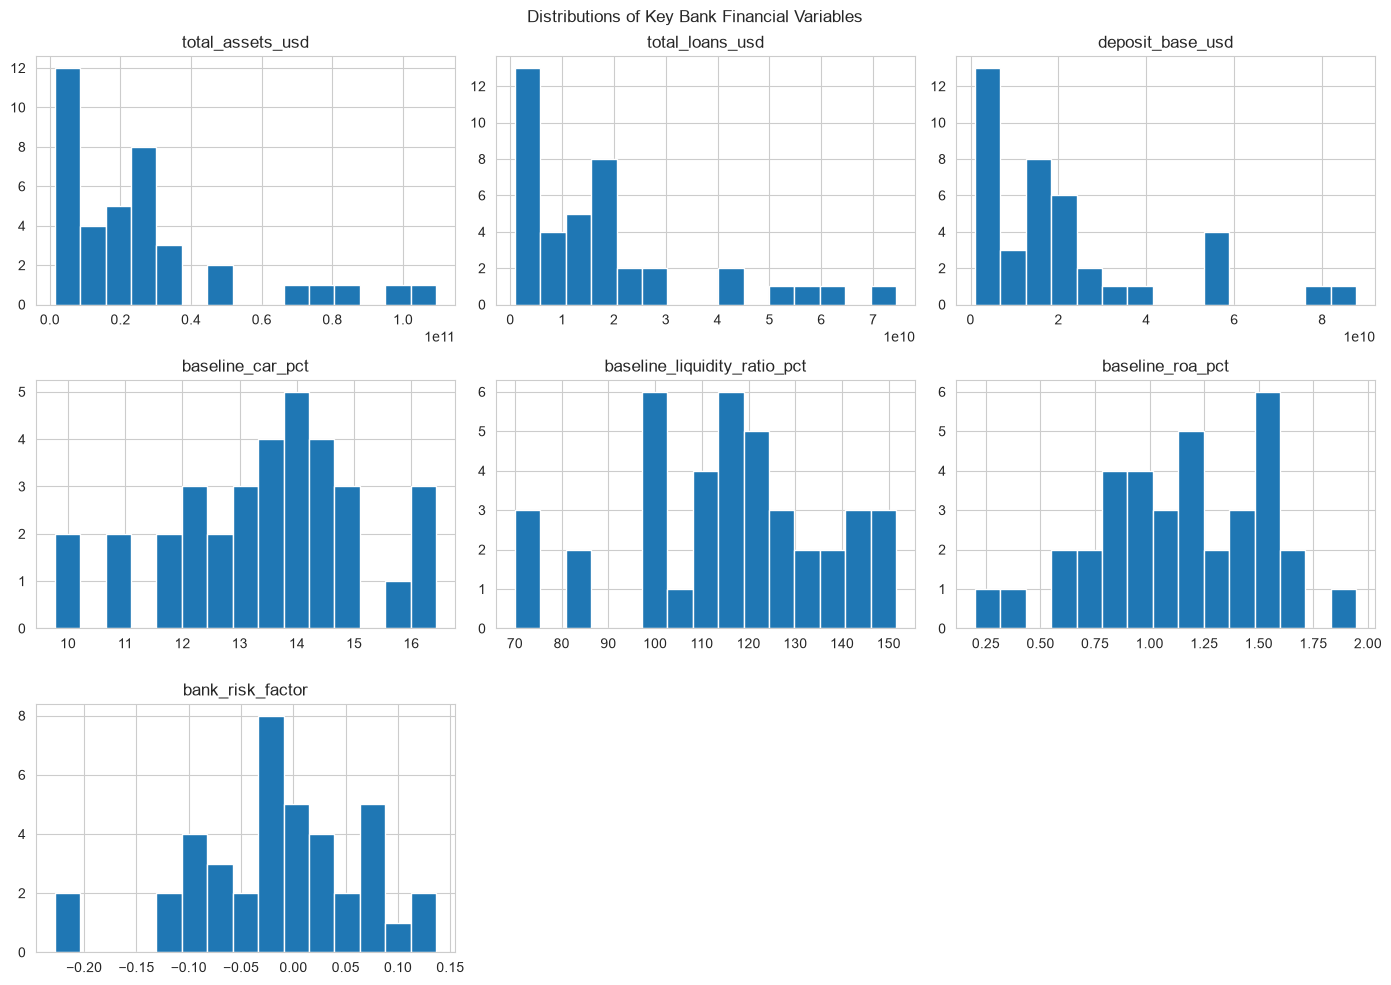

In [60]:
financial_cols = [
    "total_assets_usd",
    "total_loans_usd",
    "deposit_base_usd",
    "baseline_car_pct",
    "baseline_liquidity_ratio_pct",
    "baseline_roa_pct",
    "bank_risk_factor"
]

bank_clean[financial_cols].hist(
    figsize=(14, 10),
    bins=15
)

plt.suptitle("Distributions of Key Bank Financial Variables")
plt.tight_layout()
plt.show()

### Conclusion — Post-Cleaning EDA

The cleaned `bank_profiles.csv` dataset contains 40 banks. The descriptive analysis shows variation in bank size, loans, deposits, capital adequacy, liquidity, and profitability across the banks.

The average baseline CAR is approximately 13.43%, while the average liquidity ratio is approximately 115.97% and average ROA is approximately 1.15%. The sector-weight variables also show differences in banks' exposure across sectors.

These patterns provide a baseline view of the banks before applying stress scenarios. The next dataset will examine how banks respond under different stress conditions.